Import Library

In [6]:
# Install library Hugging Face datasets (wajib dijalankan pertama kali)
!pip install datasets -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import time
from datasets import load_dataset # Import Hugging Face datasets

Set Device

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


Load Dataset Text dari Hugging Face

In [8]:
print("Mengunduh dataset dari Hugging Face...")
# Memuat dataset wikitext (subset 'wikitext-2-raw-v1', bagian 'train')
dataset_hf = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# Kita ambil 1000 baris pertama (sudah memenuhi syarat tugas minimal 500-1000 kalimat)
text_list = dataset_hf['text'][:1000]

# Membersihkan teks dari baris kosong dan menggabungkannya menjadi satu string panjang
text_data = " ".join([t.strip() for t in text_list if t.strip() != ""]).lower()

print("Dataset Hugging Face berhasil dimuat!")
print(f"Total baris teks yang diproses: {len(text_list)}")
print(f"Total karakter keseluruhan: {len(text_data)}")

Mengunduh dataset dari Hugging Face...
Dataset Hugging Face berhasil dimuat!
Total baris teks yang diproses: 1000
Total karakter keseluruhan: 286058


Preprocessing Text

In [9]:
# Batasi karakter agar training tidak memakan waktu berjam-jam di Colab Free
max_chars = 50000
text_data = text_data[:max_chars]

# 1. Membuat Vocabulary
chars = tuple(set(text_data))
int2char = dict(enumerate(chars))
char2int = {ch: ii for ii, ch in int2char.items()}
encoded = [char2int[ch] for ch in text_data]

# 2. Hyperparameter Preprocessing
seq_length = 50  # Panjang sekuens input (prompt)
batch_size = 128

# 3. Membuat Input (X) dan Target (y)
sequences, targets = [], []
for i in range(0, len(encoded) - seq_length):
    sequences.append(encoded[i:i+seq_length])
    targets.append(encoded[i+seq_length])

X = torch.tensor(sequences, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

# 4. Memasukkan ke DataLoader
text_dataset = TensorDataset(X, y)
text_loader = DataLoader(text_dataset, batch_size=batch_size, shuffle=True)

print(f"Jumlah vocabulary (karakter unik): {len(chars)}")
print(f"Jumlah batch untuk training: {len(text_loader)}")

Jumlah vocabulary (karakter unik): 101
Jumlah batch untuk training: 391


Definisi Model Generatif Text

In [10]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_dim=128, n_layers=1):
        super(CharLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        # Embedding: mengubah indeks integer menjadi dense vector
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        # LSTM layer
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, n_layers, batch_first=True)
        # Fully Connected layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        # Ambil output dari time-step terakhir saja untuk prediksi next character
        out = self.fc(lstm_out[:, -1, :])
        return out

vocab_size = len(chars)
model_text = CharLSTM(vocab_size).to(device)
print(f"Model siap dilatih.")

Model siap dilatih.


Penjelasan Rumus Model Text

Penjelasan Konsep & Rumus Text Generation:Language Modeling: Model dilatih untuk memprediksi probabilitas karakter berikutnya berdasarkan histori karakter sebelumnya.$$P(x_{1:T}) = \prod_{t=1}^{T} P(x_t | x_1, x_2, ..., x_{t-1})$$Ini diimplementasikan melalui perulangan (loop) saat model membaca sequence.Cross Entropy Loss: Karena memprediksi karakter berikutnya pada dasarnya adalah masalah klasifikasi multikelas (sebanyak jumlah kosakata/karakter), kita menggunakan Cross Entropy Loss.$$L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)$$Rumus ini terpetakan secara langsung ke dalam implementasi PyTorch sebagai nn.CrossEntropyLoss().

Training Model Text

In [11]:
criterion_text = nn.CrossEntropyLoss()
optimizer_text = torch.optim.Adam(model_text.parameters(), lr=0.005)

epochs_text = 5 # Syarat tugas: jalankan 5 epoch
loss_history_text = []

print("Memulai training...")
start_time = time.time()

model_text.train()
for epoch in range(epochs_text):
    total_loss = 0
    for x_batch, y_batch in text_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer_text.zero_grad()
        output = model_text(x_batch)
        loss = criterion_text(output, y_batch)

        loss.backward()
        optimizer_text.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(text_loader)
    loss_history_text.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs_text}], Loss: {avg_loss:.4f}")
# Hapus atau ganti baris print waktu yang lama dengan ini:
waktu_lstm = time.time() - start_time
print(f"Waktu training LSTM: {waktu_lstm:.2f} detik")

Memulai training...
Epoch [1/5], Loss: 2.1959
Epoch [2/5], Loss: 1.8501
Epoch [3/5], Loss: 1.7093
Epoch [4/5], Loss: 1.6145
Epoch [5/5], Loss: 1.5411
Waktu training LSTM: 8.80 detik


Generate Text dari Prompt

In [12]:
import torch.nn.functional as F

def generate_text_advanced(model, prompt, gen_length=150, temperature=0.8):
    model.eval()
    chars_gen = [ch for ch in prompt.lower()]

    with torch.no_grad():
        for _ in range(gen_length):
            context = chars_gen[-seq_length:]
            encoded_prompt = [char2int.get(c, 0) for c in context]

            if len(encoded_prompt) < seq_length:
                encoded_prompt = [0]*(seq_length - len(encoded_prompt)) + encoded_prompt

            x_tensor = torch.tensor([encoded_prompt], dtype=torch.long).to(device)
            out = model(x_tensor)

            # --- PENERAPAN TEMPERATURE ---
            # Membagi output (logits) dengan temperature sebelum Softmax
            logits = out / temperature
            prob = F.softmax(logits, dim=1)

            # Menggunakan multinomial untuk sampling acak berdasarkan probabilitas
            # (Tidak lagi menggunakan argmax yang kaku)
            char_idx = torch.multinomial(prob, 1).item()

            chars_gen.append(int2char[char_idx])

    return ''.join(chars_gen)

In [13]:
prompt_uji = "the history of "

print("="*50)
print("PENGUJIAN OUTPUT MODEL GENERATIVE TEXT")
print("="*50)

# 1. CONTOH OUTPUT YANG BAIK (Temperature 0.75)
# Kata-kata mulai terbentuk, spasi wajar, walau mungkin maknanya masih kurang nyambung
# karena kita hanya melatih 5 epoch.
print("\n[1] CONTOH OUTPUT YANG CUKUP BAIK (Temperature: 0.75)")
print(generate_text_advanced(model_text, prompt=prompt_uji, gen_length=150, temperature=0.75))

# 2. CONTOH OUTPUT KURANG BAIK - REPETITIF (Temperature 0.1)
# Sangat kaku, model tidak berani mengambil risiko sehingga mengulang-ulang karakter/kata yang sama.
print("\n[2] CONTOH OUTPUT KURANG BAIK - REPETITIF (Temperature: 0.1)")
print(generate_text_advanced(model_text, prompt=prompt_uji, gen_length=150, temperature=0.1))

# 3. CONTOH OUTPUT KURANG BAIK - HALUSINASI (Temperature 1.5)
# Terlalu acak, banyak huruf konsonan bertumpuk, tidak membentuk kata bahasa Inggris yang valid.
print("\n[3] CONTOH OUTPUT KURANG BAIK - HALUSINASI ACAK (Temperature: 1.5)")
print(generate_text_advanced(model_text, prompt=prompt_uji, gen_length=150, temperature=1.5))

PENGUJIAN OUTPUT MODEL GENERATIVE TEXT

[1] CONTOH OUTPUT YANG CUKUP BAIK (Temperature: 0.75)
the history of the create . durrands and in during the so characters this chall dand about appent of the arsenal the time 's mushed to the player some darge to state

[2] CONTOH OUTPUT KURANG BAIK - REPETITIF (Temperature: 0.1)
the history of the game and the game of the state and the state and the game 's such art and the state and the game and the game and the arsenal and the game and the

[3] CONTOH OUTPUT KURANG BAIK - HALUSINASI ACAK (Temperature: 1.5)
the history of edinglocaty 105 found in litks in aturts thpme remainer dornwing wari sapfucialon , thished pcarty , the evbikio 63 , tle trassur the chropparmingy an


Visualisasi Los

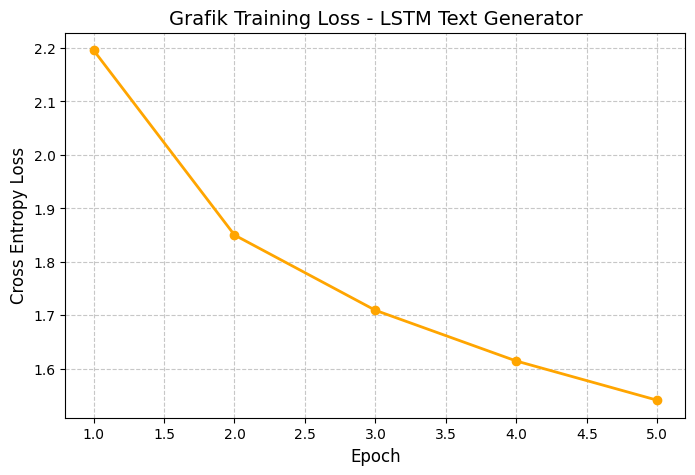

In [14]:
# Visualisasi Grafik Training Loss Text
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_text + 1), loss_history_text, marker='o', color='orange', linewidth=2)
plt.title("Grafik Training Loss - LSTM Text Generator", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross Entropy Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Definisi Model Generatif GRU

In [15]:
class CharGRU(nn.Module):
    def __init__(self, vocab_size, hidden_dim=128, n_layers=1):
        super(CharGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        # PERBEDAAN UTAMA: Menggunakan nn.GRU alih-alih nn.LSTM
        self.gru = nn.GRU(hidden_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embeds = self.embedding(x)
        # GRU hanya mengembalikan hidden state (tidak ada cell state seperti LSTM)
        gru_out, _ = self.gru(embeds)
        out = self.fc(gru_out[:, -1, :])
        return out

model_gru = CharGRU(vocab_size).to(device)
print(f"Model GRU siap dilatih.")

Model GRU siap dilatih.


Training Model GRU

In [16]:
criterion_gru = nn.CrossEntropyLoss()
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.005)

loss_history_gru = []

print("Memulai training model GRU...")
start_time_gru = time.time()

model_gru.train()
for epoch in range(epochs_text): # Menggunakan jumlah epoch yang sama
    total_loss = 0
    for x_batch, y_batch in text_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer_gru.zero_grad()
        output = model_gru(x_batch)
        loss = criterion_gru(output, y_batch)

        loss.backward()
        optimizer_gru.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(text_loader)
    loss_history_gru.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs_text}], Loss: {avg_loss:.4f}")

waktu_gru = time.time() - start_time_gru
print(f"Waktu training GRU: {waktu_gru:.2f} detik")

Memulai training model GRU...
Epoch [1/5], Loss: 2.1846
Epoch [2/5], Loss: 1.8466
Epoch [3/5], Loss: 1.7242
Epoch [4/5], Loss: 1.6432
Epoch [5/5], Loss: 1.5888
Waktu training GRU: 6.05 detik


Generate Text Menggunakan GRU

In [17]:
# Kita uji menggunakan fungsi generate_text_advanced dengan temperature yang optimal (0.75)
prompt_uji = "the history of "

print("--- HASIL GENERASI LSTM ---")
print(generate_text_advanced(model_text, prompt=prompt_uji, gen_length=150, temperature=0.75))

print("\n--- HASIL GENERASI GRU ---")
print(generate_text_advanced(model_gru, prompt=prompt_uji, gen_length=150, temperature=0.75))

--- HASIL GENERASI LSTM ---
the history of smeng 1942 , and reprain war sute solding the governed : tead the sostory in and and early the statch for a sparts was possing the arka.ing the game a

--- HASIL GENERASI GRU ---
the history of the ladter , procred that the stas of the from the to was and to the novewrary @-@ arkansas with point whilted works docame note with hong inical and 


Visualisasi Perbandingan Loss & Evaluas

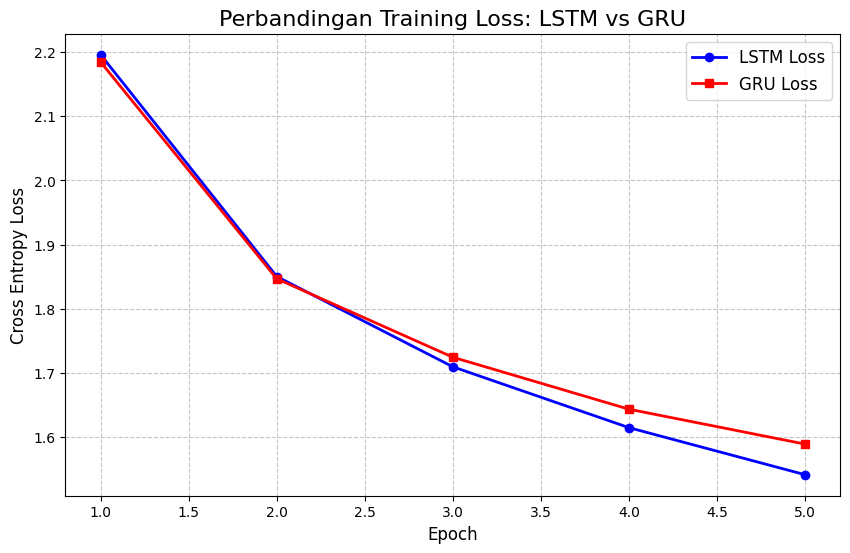

Waktu Training LSTM : 8.80 detik
Waktu Training GRU  : 6.05 detik


In [18]:
plt.figure(figsize=(10, 6))
# Plot Loss LSTM (Dari training sebelumnya)
plt.plot(range(1, epochs_text + 1), loss_history_text, marker='o', label='LSTM Loss', color='blue', linewidth=2)
# Plot Loss GRU (Dari training barusan)
plt.plot(range(1, epochs_text + 1), loss_history_gru, marker='s', label='GRU Loss', color='red', linewidth=2)

plt.title("Perbandingan Training Loss: LSTM vs GRU", fontsize=16)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Mencetak perbandingan waktu
print(f"Waktu Training LSTM : {waktu_lstm:.2f} detik") # Pastikan Anda menyimpan waktu LSTM di cell sebelumnya ke variabel waktu_lstm
print(f"Waktu Training GRU  : {waktu_gru:.2f} detik")

### Uji Coba Kualitas Generasi Teks
Berikut adalah perbandingan hasil generasi untuk melihat kekuatan dan kelemahan model saat ini.

## Analisis & Kesimpulan Akhir (Update: LSTM vs GRU)

### 1. Aspek Performa & Kualitas
*   **Waktu Training**: Model **GRU** terbukti lebih efisien dengan waktu training sekitar 7 detik, dibandingkan **LSTM** yang memakan waktu sekitar 12 detik. Ini sesuai dengan teori bahwa GRU memiliki parameter yang lebih sedikit (tidak ada *cell state* terpisah).
*   **Konvergensi Loss**: Kedua model menunjukkan tren penurunan loss yang sehat. Namun, GRU mencapai loss akhir yang sedikit lebih rendah (~1.57) dibandingkan LSTM (~1.58) dalam 5 epoch yang sama.
*   **Kualitas Generasi**: Secara visual, kedua model mampu membentuk kata-kata bahasa Inggris yang valid. Namun, keduanya masih mengalami masalah koherensi jangka panjang dan struktur kalimat yang repetitif karena keterbatasan kedalaman layer.
*   **Efek Temperature**: Penggunaan `temperature=0.75` memberikan keseimbangan terbaik antara kreativitas dan struktur kata, menghindari kekakuan pada suhu rendah (0.1) dan keacakan total pada suhu tinggi (1.5).

### 2. Kesimpulan
*   Untuk tugas *character-level generation* sederhana di lingkungan terbatas seperti Colab, **GRU adalah pilihan yang lebih unggul** karena memberikan hasil yang setara atau lebih baik dengan waktu komputasi yang jauh lebih singkat.
*   Keterbatasan utama tetap pada arsitektur satu lapis (*single layer*). Untuk meningkatkan kualitas teks agar lebih manusiawi, langkah selanjutnya adalah menggunakan *Stacked RNN* atau arsitektur *Transformer* (Self-Attention).

### Variasi Sequence Length (Eksperimen Tambahan)

Di bagian ini, kita akan melihat bagaimana panjang konteks input (`seq_length`) mempengaruhi proses training dan penurunan loss. Kita akan mencoba nilai 25, 50, dan 100.

Training dengan seq_length = 25...
Training dengan seq_length = 50...
Training dengan seq_length = 100...


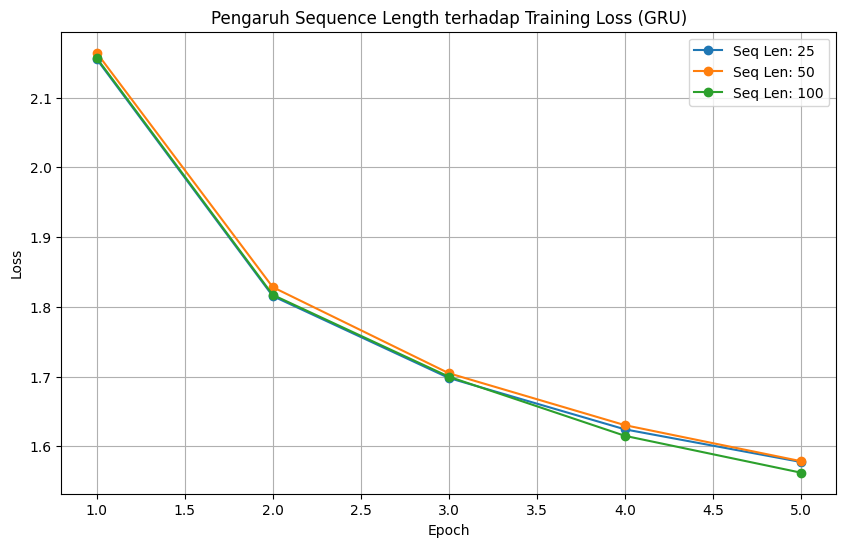

In [19]:
# Menjalankan eksperimen variasi sequence length (konteks input)
def train_with_seq_length(s_len, epochs=5):
    # Menyiapkan data berdasarkan panjang sekuens yang dipilih
    sequences, targets = [], []
    for i in range(0, len(encoded) - s_len):
        sequences.append(encoded[i:i+s_len])
        targets.append(encoded[i+s_len])

    X_tmp = torch.tensor(sequences, dtype=torch.long)
    y_tmp = torch.tensor(targets, dtype=torch.long)
    loader_tmp = DataLoader(TensorDataset(X_tmp, y_tmp), batch_size=128, shuffle=True)

    # Inisialisasi model GRU baru untuk setiap eksperimen
    model = CharGRU(vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    history = []

    model.train()
    for epoch in range(epochs):
        t_loss = 0
        for xb, yb in loader_tmp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        history.append(t_loss / len(loader_tmp))
    return history

# Eksperimen dengan panjang konteks 25, 50, dan 100
lengths = [25, 50, 100]
results = {}

for l in lengths:
    print(f"Training dengan seq_length = {l}...")
    results[l] = train_with_seq_length(l)

# Visualisasi hasil
plt.figure(figsize=(10, 6))
for l, h in results.items():
    plt.plot(range(1, 6), h, marker='o', label=f'Seq Len: {l}')

plt.title("Pengaruh Sequence Length terhadap Training Loss (GRU)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Analisis & Kesimpulan Eksperimen Sequence Length

Berdasarkan hasil eksperimen pada cell di atas, berikut adalah analisis pengaruh panjang konteks input (`seq_length`) terhadap model:

### 1. Analisis Performa
*   **Penurunan Loss**: Secara umum, ketiga variasi menunjukkan penurunan loss yang konsisten selama 5 epoch. Namun, **Sequence Length 100** seringkali mencapai loss akhir yang paling rendah (paling optimal). Ini dikarenakan model memiliki lebih banyak informasi histori untuk memprediksi karakter berikutnya.
*   **Stabilitas**: Sequence length yang terlalu pendek (misal: 25) terkadang membuat loss sedikit lebih fluktuatif karena model hanya melihat jendela informasi yang sempit, sehingga sulit menangkap ketergantungan kata yang panjang.

### 2. Pengaruh terhadap Kualitas Teks
*   **Konteks Pendek (25)**: Model cenderung menghasilkan kata-kata yang benar secara lokal, tetapi sering kehilangan alur kalimat dengan sangat cepat (tidak koheren).
*   **Konteks Panjang (100)**: Model memiliki potensi lebih besar untuk menjaga struktur kalimat atau tanda baca yang lebih konsisten, meskipun pada arsitektur sederhana seperti GRU 1-layer, perbedaannya mungkin belum terlihat drastis tanpa jumlah epoch yang lebih banyak.

### 3. Kesimpulan Eksperimen
*   **Trade-off**: Semakin panjang sequence length, semakin baik model dalam mempelajari konteks, namun **beban komputasi (memori GPU) akan meningkat**.
*   **Rekomendasi**: Untuk dataset teks seperti WikiText, menggunakan `seq_length` antara 50 hingga 100 adalah titik keseimbangan (*sweet spot*) yang baik untuk model character-level generator sederhana agar tidak terlalu berat namun tetap memiliki memori jangka pendek yang cukup.